## 目标与运行方法

下载完整 `.ipynb`，在 VibeIt Studio 文件浏览器中使用 **+ → Import from Files** 导入并打开。按从上到下的顺序运行代码单元；阅读模式中的图表是已保存的真实运行输出。重新运行会从内嵌数据计算结果。

本课适合具备 Python 基础的本科生。先阅读每一步的方法与图注，再修改参数。AI 练习为可选部分，不需要 AI 账号即可完成核心课程。数据写在 notebook metadata 中，不需要另下载数据文件。请保持 notebook 已保存到当前工作文件夹。

学习任务是理解本课的研究问题、执行透明的计算、校验结果，并说明结论的边界。

## 环境与参数

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ph04-heat'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### 读取内嵌快照

下面的加载函数按课程 ID 与 SHA-256 在当前文件夹定位本 notebook，解压后再次校验。文件改名不影响匹配。若找不到数据，确认当前工作目录与文件位置；不要用编造的数据替换它。metadata 随 `.ipynb` 保存及导出，复制代码到单独 `.py` 不会自动复制数据。

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'models': '48fd2e6e706650fe2ee0c0ad80b6d794a546a1dec78dd9d370ac09db3cc3adbf'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['models']


### 方法函数

本课所需函数的完整代码就在下面。它们只使用已列出的预装包与标准库，运行时不会导入任何 cookbook 辅助模块。先检查输入约束和返回值；如果修改算法，后面的校验也需要继续通过。

In [3]:
def heat_diffusion_explicit(nodes=51,length_m=1,alpha=1e-4,duration_s=600,ratio=.4,ambient=20,amplitude=50):
    """FTCS heat equation with fixed-temperature ends and a known sine-mode initial condition."""
    if nodes<3 or length_m<=0 or alpha<=0 or duration_s<=0 or not 0<ratio<=.5:
        raise ValueError('Require >=3 nodes, positive parameters and FTCS ratio <=0.5')
    x=np.linspace(0,length_m,nodes);spacing=x[1]-x[0]
    count=int(np.ceil(duration_s/(ratio*spacing**2/alpha)));dt=duration_s/count;actual_ratio=alpha*dt/spacing**2
    times=np.linspace(0,duration_s,count+1);temperature=np.empty((count+1,nodes))
    temperature[0]=ambient+amplitude*np.sin(np.pi*x/length_m);temperature[:,0]=ambient;temperature[:,-1]=ambient
    for j in range(count):
        temperature[j+1,1:-1]=temperature[j,1:-1]+actual_ratio*(temperature[j,2:]-2*temperature[j,1:-1]+temperature[j,:-2])
    return dict(x=x,t=times,temperature=temperature,spacing_m=spacing,step_s=dt,ratio=actual_ratio)

print("Method ready: heat_diffusion_explicit")


Method ready: heat_diffusion_explicit


### 数据与模型边界

单摆、振子、抛体和温度轨迹是明确声明的数值模型，不是实验室测量。使用的 g0 为约定标准重力加速度。GW150914 使用真实冻结应变和已发表事件时间；滤波曲线不是独立的显著性或源参数分析。黑体曲线假定理想辐射体。

## 分步分析

### 1. 遵守显式稳定性上限

一维 FTCS 的 r=alpha·dt/dx² 不得超过 0.5。两端温度固定为环境温度。初始正弦分布具有闭式解，可作为求解器的有效参考。

Actual dx (m): 0.02 ; dt (s): 1.6 ; r: 0.4


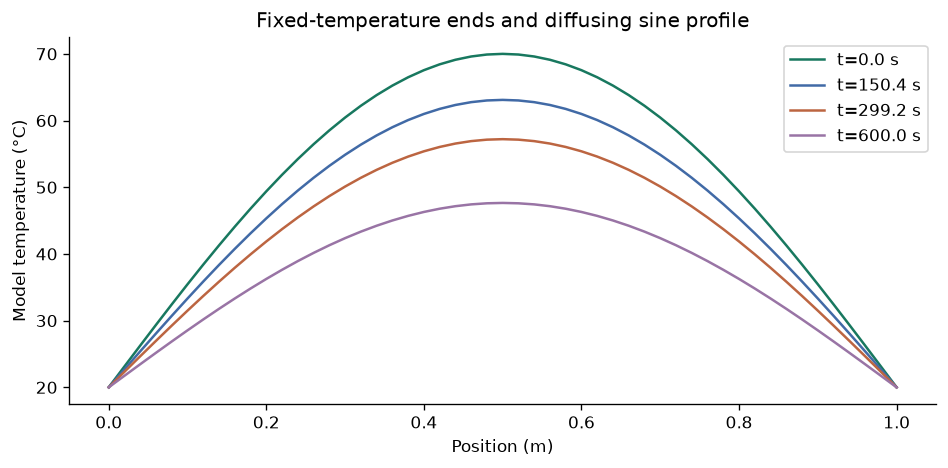

In [4]:
p=snapshot("models")["heat"]
solution=heat_diffusion_explicit(51,p["length_m"],p["diffusivity_m2_per_s"],600,.4,p["ambient_degC"],p["amplitude_degC"])
print("Actual dx (m):",solution["spacing_m"],"; dt (s):",solution["step_s"],"; r:",solution["ratio"])
fig,ax=plt.subplots(figsize=(8,4))
for time in [0,150,300,600]:
 index=int(np.argmin(abs(solution["t"]-time)));ax.plot(solution["x"],solution["temperature"][index],label=f"t={solution['t'][index]:.1f} s")
ax.set(xlabel="Position (m)",ylabel="Model temperature (°C)",title="Fixed-temperature ends and diffusing sine profile");ax.legend();plt.tight_layout();plt.show()


### 2. 观察计算温度场

颜色表示 °C 温度，横轴为米，纵轴为秒。冷却来自固定端点热库带走热量；孤立系统的能量守恒需要不同边界条件。

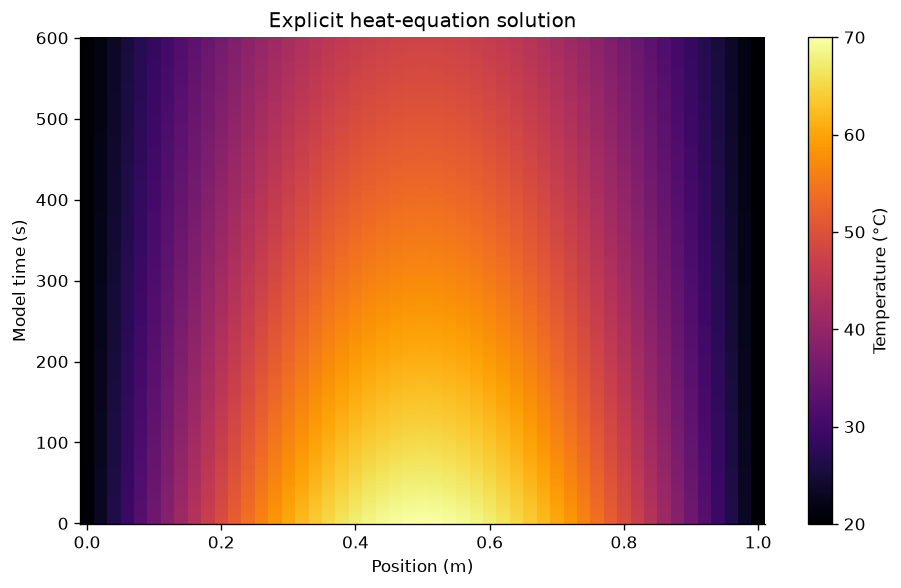

In [5]:
fig,ax=plt.subplots(figsize=(8,5));im=ax.pcolormesh(solution["x"],solution["t"],solution["temperature"],shading="auto",cmap="inferno")
ax.set(xlabel="Position (m)",ylabel="Model time (s)",title="Explicit heat-equation solution");fig.colorbar(im,ax=ax,label="Temperature (°C)");plt.tight_layout();plt.show()


### 3. 测量时空网格联合收敛

保持 r 不变细化 x，dt 也随之细化。将末时分布与 T0+A sin(pi x/L) exp(−alpha(pi/L)²t) 比较。这是受控模型数值误差基准，不是材料参数不确定性。

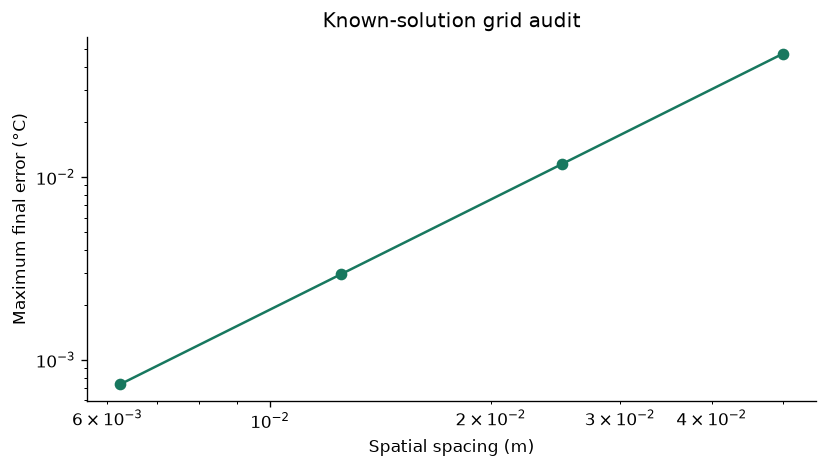

In [6]:
nodes=[21,41,81,161];records=[]
for count in nodes:
 trial=heat_diffusion_explicit(count,p["length_m"],p["diffusivity_m2_per_s"],600,.4,p["ambient_degC"],p["amplitude_degC"])
 exact=p["ambient_degC"]+p["amplitude_degC"]*np.sin(np.pi*trial["x"]/p["length_m"])*np.exp(-p["diffusivity_m2_per_s"]*(np.pi/p["length_m"])**2*600)
 records.append({"nodes":count,"dx_m":trial["spacing_m"],"dt_s":trial["step_s"],"max_error_degC":float(np.max(abs(trial["temperature"][-1]-exact)))})
convergence=pd.DataFrame(records)
fig,ax=plt.subplots(figsize=(7,4));ax.loglog(convergence.dx_m,convergence.max_error_degC,"o-")
ax.set(xlabel="Spatial spacing (m)",ylabel="Maximum final error (°C)",title="Known-solution grid audit");plt.tight_layout();plt.show()


### 4. 测试非法稳定性设置并导出

实现拒绝 r>0.5。检查固定端点、温度范围及递减的网格误差。记录请求 r 与实际 dt，避免步数取整遮盖真实格式。

In [7]:
try:heat_diffusion_explicit(ratio=.7)
except ValueError:print("Unstable FTCS ratio rejected")
else:raise AssertionError("Unstable ratio accepted")
assert np.allclose(solution["temperature"][:,[0,-1]],p["ambient_degC"])
assert solution["temperature"].min()>=p["ambient_degC"]-1e-9
assert np.all(np.diff(convergence.max_error_degC)<0)
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame(solution["temperature"],index=solution["t"],columns=solution["x"]).to_csv(OUTPUT_DIR/"temperature-field.csv")
convergence.to_csv(OUTPUT_DIR/"grid-convergence.csv",index=False)
print("Boundary, stability and refinement checks passed; exports:",OUTPUT_DIR)


Unstable FTCS ratio rejected
Boundary, stability and refinement checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ph04-heat


## 自主练习与参考答案

1. 解释允许 dt 如何依赖 dx。
2. 为何此边界下的总超温积分会下降？

**参考解释。** 稳定 dt 按 dx²/alpha 缩放。固定温度端点与热库交换热量，系统不是孤立的。

先保留当前 notebook 副本，再修改参数。把新图与原图一起比较，并记录改变了哪些输入、哪些计算和哪些结论。

## 可选的 AI 编程练习

在 VibeIt 的 Coding Agent 中打开当前 notebook，先让助手阅读相关单元。核心课程不依赖 AI 服务；服务可用性与账号设置以应用帮助中心为准。

**提示词 1**

> 仅用 NumPy、Pandas、Matplotlib 在同一空间网格比较 r=.2、.4，记录实际 dt。

**提示词 2**

> 使用同样的包增加末时解析/数值分布及误差子图。

**人工验收。** 拒绝 r>.5，保持固定端点，按正弦模态解核对网格收敛。

检查修改后的源代码，再手动运行受影响单元及后续校验。要求助手解释修改的目的、使用的包和数据来源，并用实际输出核对解释。

## 可选联网扩展

默认关闭下面的联网操作。它只显示数据库版本及快照来源，不会替换核心数据。若要重新获取数据，应另存一个实验版本并记录新的 URL、数据库版本、获取日期与 SHA-256；新版结果需要重新执行和核验。

In [8]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## 来源、快照与下一步

- [IAPWS saturation reference release](https://iapws.org/public/documents/6dGkr/Supp-sat.pdf) — IAPWS SR1-86(1992): unrestricted publication allowed in all countries (cover page); retrieved 2026-10-09. SHA-256 `a10d38d73339b0713c86cfac88f9adcba137202167ccdfa1cd58238c438361d7`.
  Reference equations and numerical coefficients transcribed from release pages 2–3; pedagogical model values are not new experiments.

- [Authored numerical teaching model parameters](https://github.com/zhiluo20/vibeit/blob/main/cookbook-src/freeze_subject_data.py) — Original teaching parameters/code MIT; reference equation coefficients attributed to IAPWS SR1-86(1992); retrieved 2026-10-09. SHA-256 `4350c4305a83c772fa295a8be0ef86a247f2bfaae930a081720d3cd0c753abe0`.
  Declared parameters and seed; generated trajectories and calibration observations must be labelled simulated.


**下一步。** 在保留本课的数据检查、参数记录和结果校验之后，将相同方法用于自己的公开或已获授权数据。记录研究设计与方法限制，不把示例结果当成新实验的验证。完整数据许可与生成说明见 cookbook 网页。